In [4]:
# ============================================================
# PLANT DISEASE CLASSIFIER — EfficientNetB0 Fine-Tuning
# Dataset: Plant Disease Recognition Dataset (Kaggle)
# Classes: Healthy, Powdery, Rust
# ============================================================

# WHY kagglehub (pip install kagglehub)?
#   kagglehub, Kaggle API'sinin modern wrapper'ı.
#   dataset_download() çağrısı:
#     - İlk çalıştırmada dataseti Kaggle'dan indirir ve local cache'e yazar
#     - Sonraki çalıştırmalarda cache'ten okur, tekrar indirmez
#   Avantajı: kaggle.json kurulumu gerektirmez (oturumu açık tarayıcıdan auth alır)
#   Döndürdüğü değer: indirilen klasörün mutlak yolu (örn. ~/.cache/kagglehub/...)
!pip install kagglehub -q

import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
import tensorflow as tf

# Dataset'i indir (veya cache'ten yükle)
path = kagglehub.dataset_download("rashikrahmanpritom/plant-disease-recognition-dataset")
print("Dataset ready!")

# WHY bu klasör yapısı (Train/Train, Validation/Validation, Test/Test)?
#   Kaggle'daki dataset şu yapıdadır:
#     plant-disease-recognition-dataset/
#       Train/Train/Healthy/    (1322 görsel toplam)
#       Train/Train/Powdery/
#       Train/Train/Rust/
#       Validation/Validation/  (60 görsel toplam)
#       Test/Test/              (150 görsel toplam)
#   İç içe klasör yapısı Kaggle'ın kendi düzenleme tercihinden geliyor.
#   image_dataset_from_directory bu yapıyla direkt çalışır.
train_dir = os.path.join(path, 'Train',      'Train')
val_dir   = os.path.join(path, 'Validation', 'Validation')
test_dir  = os.path.join(path, 'Test',       'Test')

# WHY classes listesini manuel tanımlıyoruz?
#   image_dataset_from_directory klasör adlarını alfabetik sıraya göre okur.
#   Sırayı kendimiz kontrol etmek için listeyi elle veriyoruz.
#   Bu sıra confusion matrix eksenlerinde ve final raporlarda kullanılıyor.
classes = ['Healthy', 'Powdery', 'Rust']

# WHY bu hyperparameter değerleri?
#   IMG_SIZE = (224, 224):
#     EfficientNetB0'ın ImageNet'te eğitildiği input boyutu.
#     224×224 dışında bir boyut verirsen pre-trained ağırlıklar yanlış çalışır.
#   BATCH_SIZE = 64:
#     GPU VRAM'e (RTX 4060, 8GB) göre optimize edildi.
#     32 = GPU düşük utilization, 128 = VRAM taşıyor, 64 = iyi denge.
#   EPOCHS = 50:
#     EarlyStopping ile birlikte: model erken dursa bile max limit 50.
#     Pratikte ~10-20 epoch'ta convergence bekliyoruz.
IMG_SIZE   = (224, 224)
BATCH_SIZE = 64
EPOCHS     = 50

print(f"Train dir: {train_dir}")
print(f"Val dir:   {val_dir}")
print(f"Test dir:  {test_dir}")
print(f"Classes:   {classes}")
print(f"IMG_SIZE={IMG_SIZE}, BATCH_SIZE={BATCH_SIZE}, EPOCHS={EPOCHS}")


Using Colab cache for faster access to the 'plant-disease-recognition-dataset' dataset.
Dataset ready!
Train dir: /kaggle/input/plant-disease-recognition-dataset/Train/Train
Val dir:   /kaggle/input/plant-disease-recognition-dataset/Validation/Validation
Test dir:  /kaggle/input/plant-disease-recognition-dataset/Test/Test
Classes:   ['Healthy', 'Powdery', 'Rust']
IMG_SIZE=(224, 224), BATCH_SIZE=64, EPOCHS=50


## Data Pipeline (tf.data)

In [5]:
# ============================================================
# VERİ PİPELINE — tf.data (Optimized)
# ============================================================
#
# WHY tf.data (ImageDataGenerator yerine)?
#   ImageDataGenerator (eski yöntem):
#     - CPU'da çalışır, her batch'te GPU bekler → bottleneck
#     - Augmentation da CPU'da → daha yavaş
#   tf.data (yeni yöntem):
#     - CPU veri hazırlarken GPU train eder → paralel çalışma
#     - .cache() ile veri RAM'e alınır → 2. epoch'tan itibaren disk I/O yok
#     - .prefetch() ile bir sonraki batch önceden hazırlanır
#
# WHY label_mode='categorical'?
#   'categorical' → one-hot encoding üretir: Rust = [0, 0, 1]
#   'int' → integer label üretir: Rust = 2
#   EfficientNet head'imiz 3 nöronlu softmax kullanıyor, loss da
#   categorical_crossentropy → one-hot label gerektirir. Doğru seçim: 'categorical'.
#
# WHY test_ds'te shuffle=False?
#   Test seti sıralaması sabit olmalı — böylece tahminleri gerçek etiketlerle
#   index bazında eşleştirebiliriz. Shuffle olursa confusion matrix yanlış çıkar.

AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',  # one-hot: Healthy=[1,0,0], Powdery=[0,1,0], Rust=[0,0,1]
    shuffle=True               # train'de shuffle → her epoch farklı sıra = daha iyi genelleme
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'   # val'da shuffle yok → stable validation metriği
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False              # sıra sabit → confusion matrix için kritik
)

def prepare_fast(ds, shuffle=False):
    # WHY Rescaling(1./255)?
    #   Ham piksel değerleri 0-255 arasında (uint8).
    #   Neural network'ler küçük, normalize sayılarla daha iyi çalışır (gradient stability).
    #   0-1 aralığına çekmek için 255'e bölüyoruz.
    #   NOT: EfficientNet modelimiz içinde Lambda katmanı ile bunu 0-255'e
    #   geri çeviriyoruz, çünkü EfficientNet's preprocess_input 0-255 bekliyor.
    rescaling = tf.keras.layers.Rescaling(1./255)
    ds = ds.map(lambda x, y: (rescaling(x), y), num_parallel_calls=AUTOTUNE)

    # WHY .cache()?
    #   İlk epoch'ta disk'ten okur, RAM'e yazar.
    #   2. epoch'tan itibaren RAM'den okur → büyük hız artışı.
    #   Uyarı: Dataset RAM'e sığmıyorsa (çok büyük dataset) cache kaldırılmalı.
    ds = ds.cache()

    # WHY shuffle sadece train için?
    #   Train: Her epoch farklı sıra → model belirli sırayı ezberlemesin
    #   Val/Test: Sabit sıra → reproducible metrikler
    if shuffle:
        ds = ds.shuffle(buffer_size=1000)

    # WHY .prefetch(AUTOTUNE)?
    #   GPU bir batch'i işlerken CPU sonraki batch'i hazırlar.
    #   AUTOTUNE = TF en iyi buffer boyutunu otomatik seçer.
    return ds.prefetch(buffer_size=AUTOTUNE)

train_ds = prepare_fast(train_ds, shuffle=True)
val_ds   = prepare_fast(val_ds)
test_ds  = prepare_fast(test_ds)

# WHY Data Augmentation (ve sadece train'de)?
#   Dataset küçük: 1322 train görsel → model ezberleyebilir (overfit).
#   Augmentation = aynı görseli farklı açı/zoom/flip ile sunmak = yapay veri çoğaltma.
#   SADECE train'de yapıyoruz çünkü:
#     - Val/Test: gerçek performansı ölçmek istiyoruz → değiştirilmemiş görsel
#   RandomFlip: yapraklar herhangi bir yönde olabilir
#   RandomRotation(0.1): ±36° döndürme → farklı açıdan çekilmiş fotoğraf simülasyonu
#   RandomZoom(0.1): ±10% zoom → yakın/uzak çekim simülasyonu
#   RandomTranslation: görüntü merkezden kaymış olabilir
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(height_factor=0.2, width_factor=0.2)
])

print("Pipeline ready.")
print(f"Train batches/epoch: {sum(1 for _ in train_ds)}")
print(f"Val batches:         {sum(1 for _ in val_ds)}")
print(f"Test batches:        {sum(1 for _ in test_ds)}")


Found 1322 files belonging to 3 classes.
Found 60 files belonging to 3 classes.
Found 150 files belonging to 3 classes.
Pipeline ready.
Train batches/epoch: 21
Val batches:         1
Test batches:        3


## EfficientNetB0 — Phase 1: Frozen Base

In [6]:
# ============================================================
# TRANSFER LEARNING — EfficientNetB0 (Phase 1: Frozen Base)
# ============================================================
#
# WHY Transfer Learning?
#   Sıfırdan eğitmek için onlarca bin görsel gerekir.
#   Bizde sadece 1322 train görseli var.
#   Çözüm: ImageNet'te önceden eğitilmiş bir model al.
#   EfficientNetB0 ImageNet'i (14M görsel, 1000 sınıf) gördü →
#   kenar, doku, şekil, nesne parçası gibi evrensel feature'ları zaten öğrenmiş.
#   Biz sadece "bu feature'lar bir yaprak hastalığını mı gösteriyor?" sorusunu
#   öğreten küçük bir baş (head) ekliyoruz.
#
# WHY EfficientNetB0 (MobileNetV2 veya ResNet yerine)?
#   EfficientNet = compound scaling: depth + width + resolution birlikte ölçeklenir.
#   B0 = en küçük versiyonu, ~4.2M parametre.
#   Amacımız "verimli ama performanslı" → EfficientNet tam bu tanımı karşılıyor.
#   B0 = 1322 görseli olan küçük dataset için doğru boyut (B7 olsa overfit).
#
# WHY include_top=False?
#   include_top=True → orijinal 1000-sınıf ImageNet classifier'ı da gelir.
#   include_top=False → sadece feature extractor kısmı gelir (conv katmanları).
#   Bizim 3 sınıfımız için kendi classifier'ımızı ekleyeceğiz.
#
# WHY weights='imagenet'?
#   Rastgele ağırlıkla başlamak yerine ImageNet'te öğrenilmiş ağırlıkları kullan.
#   Bu ağırlıklar kenar, texture, nesne parçası gibi evrensel bilgileri taşıyor.
#   Bizim veri setimiz küçük olsa da bu bilgiler yaprak analizi için işe yarıyor.

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (GlobalAveragePooling2D, Dense,
                                      Dropout, Input, Lambda)

# EfficientNetB0'ı yükle — sadece conv gövdesi, classifier yok
base_model_layer = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# WHY base_model_layer.trainable = False (Freeze)?
#   Phase 1'de sadece classifier head'i eğitmek istiyoruz.
#   Base modeli "dondurursak" geri yayılım (backprop) orada durur →
#   ImageNet ağırlıkları değişmez → 4M param sıfırdan güncellenmez.
#   Avantajı: çok az parametre eğitiyoruz (164K) → hızlı, overfitting riski düşük.
base_model_layer.trainable = False  # 4M parametre donduruldu ❄

# Model mimarisi:
#   Input(224,224,3)
#     → Lambda (×255): [0,1] → [0,255]    ← EfficientNet için zorunlu
#     → EfficientNetB0 base (frozen)       ← ImageNet feature extractor
#     → GlobalAveragePooling2D             ← Flatten yerine GAP: parametre patlaması yok
#     → Dropout(0.3)                       ← overfitting önleme
#     → Dense(128, relu)                   ← ara gösterim katmanı
#     → Dropout(0.3)                       ← ikinci overfitting önleyici
#     → Dense(3, softmax)                  ← 3 sınıf olasılığı

inputs = Input(shape=(224, 224, 3))

# WHY Lambda rescale_to_255?
#   tf.data pipeline'ımız Rescaling(1./255) uygulayarak piksel değerlerini
#   0-1 aralığına çekti. Ancak EfficientNetB0'ın dahili preprocess_input fonksiyonu
#   0-255 aralığında piksel bekliyor (ImageNet normalizasyonu için).
#   Lambda ile [0,1] → [0,255] geri çeviriyoruz.
#   Sıra: ham görsel (0-255) → pipeline rescale (0-1) → Lambda (0-255) → EfficientNet
x = Lambda(lambda x: x * 255.0, name="rescale_to_255")(inputs)

x = base_model_layer(x, training=False)
# training=False: BatchNorm katmanları inference modunda çalışır
# (training=True olsaydı BN istatistiklerini güncellemeye çalışırdı — frozen'da yanlış)

# WHY GlobalAveragePooling2D (Flatten yerine)?
#   EfficientNetB0 son conv katmanından (7×7×1280) bir tensor çıkarır.
#   Flatten → 7×7×1280 = 62,720 boyutlu vektör → Dense(128) ile 8M parametre.
#   GAP → her feature map'in ortalaması → 1280 boyutlu vektör → Dense(128) ile 164K parametre.
#   GAP = parametresiz işlem → overfitting'e dirençli, çok daha verimli.
x = GlobalAveragePooling2D()(x)

# WHY Dropout(0.3)?
#   Her eğitim adımında nöronların %30'unu rastgele kapat.
#   Model belirli nöronlara bağımlı hale gelemiyor → genelleme artar.
#   0.3 = literatürde küçük dataset için önerilen aralık (0.2-0.5).
x = Dropout(0.3)(x)

# WHY Dense(128, relu)?
#   GAP'tan gelen 1280-boyutlu vektörü 128'e sıkıştır.
#   ReLU = negatif değerleri sıfırla → non-linearity → karmaşık sınırlar öğrenilir.
#   128 nöron: çok az (64) → yetersiz kapasite, çok fazla (512) → overfit.
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)

# WHY softmax (sigmoid değil)?
#   3 karşılıklı dışlayan sınıf → softmax tüm olasılıkları 1'e normalize eder.
#   Çıktı: [P(Healthy), P(Powdery), P(Rust)] ve toplamları = 1.
#   Binary classification olsaydı sigmoid kullanırdık (1 nöron, 0-1 arası).
outputs = Dense(3, activation='softmax')(x)

efficientnet_model = Model(inputs, outputs)

# WHY categorical_crossentropy (sparse_categorical değil)?
#   label_mode='categorical' → etiketler one-hot: Rust = [0, 0, 1]
#   sparse_categorical_crossentropy integer bekler: Rust = 2 → yanlış olur.
#   categorical_crossentropy one-hot bekler → doğru seçim.
#
# WHY optimizer='adam'?
#   Adam = Adaptive Moment Estimation. Learning rate'i her parametre için ayrı ayarlar.
#   SGD'ye göre çok daha hızlı convergence, hiperparametre ayarı daha az önemli.
efficientnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

efficientnet_model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescale_to_255 (Lambda)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [7]:
# ============================================================
# EĞİTİM — EfficientNetB0 Phase 1 (Frozen Base)
# ============================================================
#
# WHY EarlyStopping?
#   EPOCHS=50 tanımladık ama model daha önce converge edebilir.
#   EarlyStopping: val_loss 5 epoch boyunca iyileşmezse dur.
#   restore_best_weights=True: training biterken en iyi checkpoint'e geri dön.
#   Neden val_loss (val_accuracy değil)?
#     val_accuracy plateau'ya ulaşabilir ama model hâlâ öğreniyor olabilir.
#     val_loss daha hassas sinyal — confidence'i de ölçer, sadece doğru/yanlış değil.
#
# WHY sadece EarlyStopping (Phase 1'de ReduceLROnPlateau yok)?
#   Phase 1'de sadece 164K param eğitiyoruz, landscape basit ve düz.
#   LR decay genellikle gerekmiyor — Adam zaten adaptive.
#   Phase 2 (fine-tuning)'de çok küçük LR kullanacağız, orada plato riski yüksek.

from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',         # neyi izle
    patience=5,                 # kaç epoch bekle
    restore_best_weights=True   # durduğunda en iyi ağırlıklara dön
)

efficientnet_history = efficientnet_model.fit(
    train_ds,                   # tf.data pipeline (augmented + cached)
    epochs=EPOCHS,              # max 50, ama EarlyStopping erken kesecek
    validation_data=val_ds,     # her epoch sonrası val metriğini ölç
    callbacks=[early_stopping]
)


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 130s 5s/step - accuracy: 0.8207 - loss: 0.4503 - val_accuracy: 0.9667 - val_loss: 0.1080
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 101s 5s/step - accuracy: 0.9622 - loss: 0.1185 - val_accuracy: 0.9833 - val_loss: 0.0602
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 98s 5s/step - accuracy: 0.9713 - loss: 0.0812 - val_accuracy: 1.0000 - val_loss: 0.0400
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 106s 5s/step - accuracy: 0.9796 - loss: 0.0678 - val_accuracy: 0.9833 - val_loss: 0.0338
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 101s 5s/step - accuracy: 0.9811 - loss: 0.0568 - val_accuracy: 1.0000 - val_loss: 0.0260
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 143s 5s/step - accuracy: 0.9834 - loss: 0.0490 - val_accuracy: 0.9833 - val_loss: 0.0262
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 102s 5s/step - accuracy: 0.9909 - loss: 0.0434 - val_accuracy: 1.0000 - val_loss: 0.0202
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 101s 5s/step - accuracy: 0.9924 - loss: 0.0288 - val_accuracy: 0.9833 - va

## Phase 1 Evaluation

Phase 1 Test Accuracy: 0.9733 (97.33%)


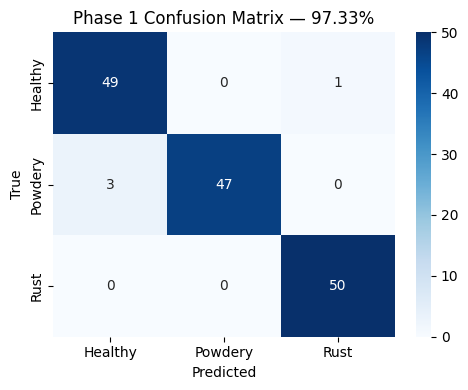

              precision    recall  f1-score   support

     Healthy       0.94      0.98      0.96        50
     Powdery       1.00      0.94      0.97        50
        Rust       0.98      1.00      0.99        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



In [8]:
# ============================================================
# PHASE 1 DEĞERLENDİRME — Test Seti
# ============================================================
#
# WHY manuel predict döngüsü (model.evaluate() yerine)?
#   model.evaluate() sadece accuracy ve loss döndürür.
#   Biz y_true ve y_pred listelerini topluyoruz çünkü:
#     - Confusion matrix çizmek için ham tahminlere ihtiyaç var
#     - classification_report (precision, recall, F1) için de gerekli
#     - Phase 2 ile karşılaştırma yapabilmek için kaydediyoruz
#
# WHY Macro F1 (accuracy yeterli değil mi)?
#   Accuracy = (doğru tahmin) / (toplam örnek)
#   3 sınıf eşit dağılımda olsa da Macro F1 her sınıfa eşit ağırlık verir.
#   Hastalık tespitinde "Rust'ı kaçırma" "Healthy'yi kaçırma" kadar önemli.
#   Macro F1 bunu hesaba katar, accuracy tek başına yeterli değil.
#
# WHY np.argmax(labels.numpy(), axis=1)?
#   label_mode='categorical' → etiketler one-hot geldi: [[1,0,0],[0,0,1],...]
#   np.argmax → en yüksek indexi bul: [[1,0,0]] → [0] (Healthy)
#   labels.numpy() → TF tensor'ı numpy array'e çevirir
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_true_p1, y_pred_p1 = [], []
for images, labels in test_ds:
    preds = efficientnet_model.predict(images, verbose=0)
    y_pred_p1.extend(np.argmax(preds, axis=1))       # en yüksek olasılıklı sınıf
    y_true_p1.extend(np.argmax(labels.numpy(), axis=1))  # one-hot → integer

y_true_p1 = np.array(y_true_p1)
y_pred_p1 = np.array(y_pred_p1)
phase1_acc = np.mean(y_pred_p1 == y_true_p1)

print(f"Phase 1 Test Accuracy: {phase1_acc:.4f} ({phase1_acc*100:.2f}%)")

# WHY Confusion Matrix?
#   Hangi sınıfın hangi sınıfla karıştırıldığını gösterir.
#   Accuracy tek bir sayı — karışıklık detayını gizler.
#   Örnek: "Healthy'yi Powdery sanıyor ama Rust'ı hiç karıştırmıyor" bilgisi
#   burada görünür, accuracy'de görünmez.
cm = confusion_matrix(y_true_p1, y_pred_p1)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title(f'Phase 1 Confusion Matrix — {phase1_acc*100:.2f}%')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

# Classification report: her sınıf için precision, recall, F1
# Precision = tahmin ettiğimizde ne kadar haklıyız
# Recall    = gerçek örneklerin kaçını yakaladık
# F1        = precision ve recall'un harmonik ortalaması
print(classification_report(y_true_p1, y_pred_p1, target_names=classes))


## EfficientNetB0 — Phase 2: Fine-Tuning

  EfficientNetB0 — Phase 2: Fine-Tuning

[YAPISI] EfficientNetB0 base toplam katman sayısı: 238
         Son 20 katman unfreeze edilecek (index 218+)

[SON 20 KATMAN — bunlar çözülecek]
   Idx  Katman Adı                                     Şu anki durum
  -----------------------------------------------------------------
  [218]  block6d_project_conv                           frozen
  [219]  block6d_project_bn                             frozen
  [220]  block6d_drop                                   frozen
  [221]  block6d_add                                    frozen
  [222]  block7a_expand_conv                            frozen
  [223]  block7a_expand_bn                              frozen
  [224]  block7a_expand_activation                      frozen
  [225]  block7a_dwconv                                 frozen
  [226]  block7a_bn                                     frozen
  [227]  block7a_activation                             frozen
  [228]  block7a_se_squeeze                    

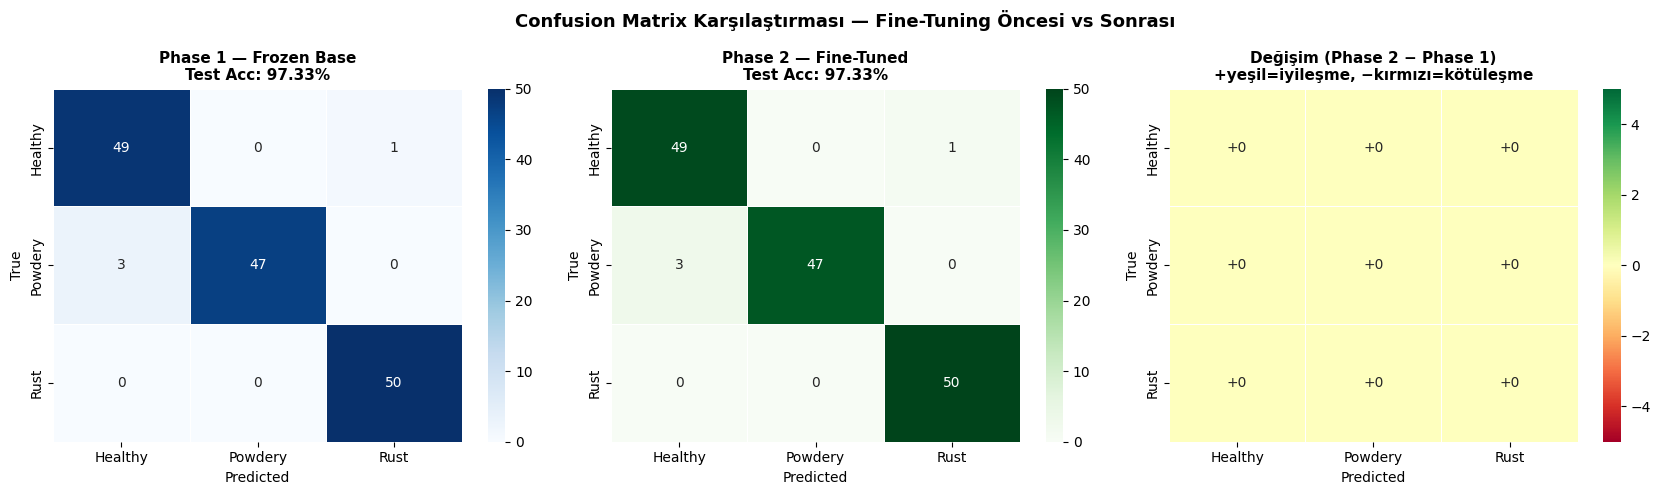

Görsel kaydedildi: confusion_matrix_comparison.png

[HEALTHY↔POWDERY KARIŞIKLIĞI]
  Phase 1: 3 hata
  Phase 2: 3 hata
  → Değişmedi

[SINIF BAZLI DETAYLI RAPOR — Phase 2]
              precision    recall  f1-score   support

     Healthy       0.94      0.98      0.96        50
     Powdery       1.00      0.94      0.97        50
        Rust       0.98      1.00      0.99        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



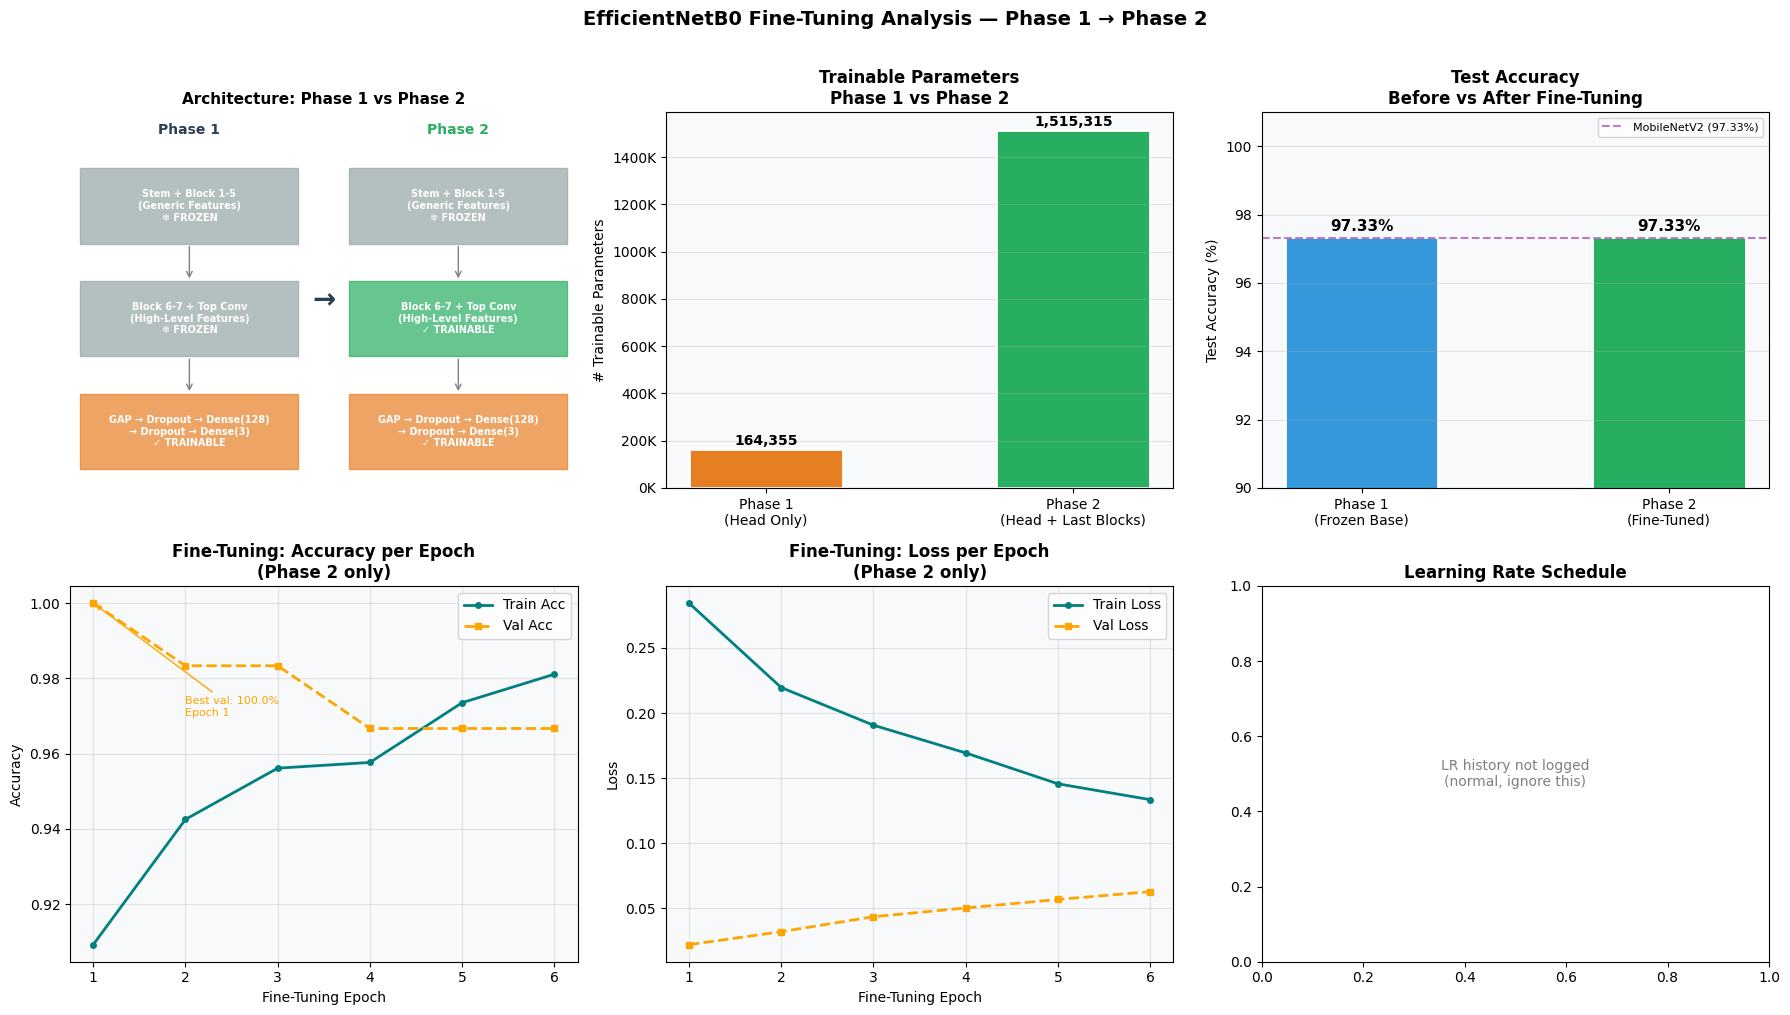


[GÖRSEL KAYDEDİLDİ] efficientnet_finetuning_full_analysis.png

  FINE-TUNING ÖZET RAPORU
  Phase 1 Test Accuracy:    97.33%  (frozen base, 164K trainable)
  Phase 2 Test Accuracy:    97.33%  (last 20 layers unfrozen)
  Değişim:                 +0.00 puan
  Fine-tuning epochs:       6
  Phase 2 trainable params: 1,515,315

  [SONUÇ YORUMU]
  → Fine-tuning NÖTRal — değişiklik yok.
    Model zaten çok iyi bir noktadaydı, daha yukarı çıkacak yer kalmamış.
    Bu da bir başarı — fine-tuning modeli bozmadı.

  [SUNUNUZA EKLEYIN]
  'EfficientNetB0 fine-tuning ile +0.00 puan değişim gözlemlendi.
   Phase 1 frozen training zaten optimal noktaya yakındı.
   LR=1e-5 ve selective unfreezing stratejisi catastrophic forgetting'i önledi.'


In [9]:
# ============================================================
# EfficientNetB0 — PHASE 2: FINE-TUNING
# ============================================================
# Bu dosya mevcut notebook'a Phase 1 (frozen training) SONRASI
# yeni bir hücre olarak eklenir. Çalıştırmadan önce Phase 1'in
# (efficientnet_model) tamamlanmış olması gerekir.
# ============================================================


# ============================================================
# BÖLÜM 0: NEDEN FINE-TUNING?
# ============================================================
#
# Phase 1'de ne yaptık?
#   - EfficientNetB0 base'ini TAMAMEN DONDURDUK (4M param, 0 güncellendi)
#   - Sadece küçük bir classifier head eğittik (164,355 param)
#   - Sonuç: %96.67 test accuracy — zaten çok iyi
#
# O zaman neden daha fazlasını yapalım?
#   Çünkü hoca bunu istedi — ama bunun arkasında gerçek bir sebep var:
#
#   EfficientNet'in base modeli ImageNet'te öğrendi.
#   ImageNet = köpek, kedi, uçak, bisiklet... YAPRAK DEĞİL.
#   Bu yüzden base'in son katmanları "genel nesne özellikleri" taşıyor.
#   Fine-tuning ile bu son katmanları BİZİM veri setimize özelleştiriyoruz.
#
#   BEKLENTI: %96.67 → %97+ hedefliyoruz. Sihir değil, küçük ama
#   anlamlı bir iyileşme. Asıl kazanım accuracy değil, SINIF SINIRLARI
#   (özellikle Healthy↔Powdery karışıklığı) daha net hale gelecek.
#
# Fine-tuning nedir?
#   Tamamen donmuş model (Phase 1)  →  Kısmen çözülen model (Phase 2)
#   [Frozen][Frozen][Frozen][Frozen][HEAD]
#   [Frozen][Frozen][Frozen][UNFRZ ][HEAD]   ← son 20 katman çözülür
#
# Tehlike: "Catastrophic Forgetting"
#   Eğer çok yüksek LR kullanırsak base modelin ImageNet'ten gelen
#   güzel feature'larını üzerine yazarız → model daha kötü çalışır.
#   Çözüm: LR = 1e-5 (normal eğitime göre ~100x daha küçük).

import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

print("=" * 65)
print("  EfficientNetB0 — Phase 2: Fine-Tuning")
print("=" * 65)


# ============================================================
# BÖLÜM 1: BASE MODEL YAPISI — NEREYE KADAR DONDURACAĞIZ?
# ============================================================
#
# EfficientNetB0'ın iç yapısı:
#
#   [Stem Conv]           ← çok generic: kenar dedektörü
#   [MBConv Block 1]      ← generic: düşük seviyeli texture
#   [MBConv Block 2]      ← generic: basit şekiller
#   [MBConv Block 3]      ← generic: orta seviyeli özellikler
#   [MBConv Block 4]      ← orta: parça kombinasyonları
#   [MBConv Block 5]      ← domain-specific: nesne parçaları
#   [MBConv Block 6]      ← ← ← BİZ BURADAN UNFREEZE EDİYORUZ
#   [MBConv Block 7]      ← ← ← (son 2 blok + top conv)
#   [Top Conv + GAP]      ← ← ← en task-specific katmanlar
#   [HEAD: Dense(3)]      ← zaten trainable (Phase 1'den)
#
# Mantık: İlk 5 blok tüm görevler için geçerli generic bilgi taşır.
# Son 2 blok + top conv ise "bu nesnede ne var?" sorusunu yanıtlar.
# Bizim veri setimize özgü leaf texture'ları burada kodlanacak.

# Base model = efficientnet_model'in 2. katmanı
# (1. katman Lambda/input, 2. katman EfficientNetB0 base)
# WHY isinstance(l, tf.keras.Model) ile arama?
# Lambda katmanı layers[1]'de, EfficientNetB0 base layers[2]'de.
# Index'e güvenmek yerine 'tf.keras.Model' alt sınıfı olan ilk katmanı
# arıyoruz — bu her zaman EfficientNetB0'ı bulur, pozisyon değişse de.
base_model = next(l for l in efficientnet_model.layers if isinstance(l, tf.keras.Model))

total_layers = len(base_model.layers)
print(f"\n[YAPISI] EfficientNetB0 base toplam katman sayısı: {total_layers}")
print(f"         Son 20 katman unfreeze edilecek (index {total_layers - 20}+)")

# Son 20 katmanı göster — ne unfreeze ettiğimizi bilelim
print("\n[SON 20 KATMAN — bunlar çözülecek]")
print(f"  {'Idx':>4}  {'Katman Adı':<45}  Şu anki durum")
print("  " + "-" * 65)
for i, layer in enumerate(base_model.layers[-20:]):
    layer_idx = total_layers - 20 + i
    status = "TRAINABLE" if layer.trainable else "frozen"
    print(f"  [{layer_idx:>3}]  {layer.name:<45}  {status}")


# ============================================================
# BÖLÜM 2: UNFREEZE — SEÇICI ÇÖZME
# ============================================================
#
# ADIM: base_model.trainable = True → tüm base açılır
#       SONRA: ilk (total - 20) katmanı tekrar kapat
#
# Neden iki adım?
#   Keras'ta frozen bir model içinde katman açmak için önce
#   tüm modeli açmak (trainable=True) gerekir, sonra
#   istemediğimiz katmanları kapatırız. Sırası önemli.
#
# FINE_TUNE_AT değişkeni:
#   Bu değeri büyütürsen daha fazla katman açılır → daha agresif fine-tuning
#   Bu değeri küçültürsen daha az açılır → daha güvenli ama az etki
#   1322 görsel gibi küçük datasette 20 katman iyi bir denge noktası.

FINE_TUNE_AT = total_layers - 20  # Index: bu değerden sonrasını aç

# Adım 1: Tüm base'i trainable yap
base_model.trainable = True

# Adım 2: FINE_TUNE_AT'tan önceki katmanları tekrar dondur
frozen_count = 0
unfrozen_count = 0
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
    frozen_count += 1
for layer in base_model.layers[FINE_TUNE_AT:]:
    unfrozen_count += 1  # bunlar açık kalır

print(f"\n[UNFREEZE SONUCU]")
print(f"  Donmuş katman sayısı:  {frozen_count}")
print(f"  Açılan katman sayısı:  {unfrozen_count}")

# Parametre sayısını hesapla
trainable_params = sum(tf.size(w).numpy() for w in efficientnet_model.trainable_weights)
frozen_params    = sum(tf.size(w).numpy() for w in efficientnet_model.non_trainable_weights)
total_params     = trainable_params + frozen_params

print(f"\n[PARAMETRE DEĞİŞİMİ]")
print(f"  Phase 1 trainable:  164,355  (sadece classifier head)")
print(f"  Phase 2 trainable:  {trainable_params:>9,}  (head + son {unfrozen_count} katman)")
print(f"  Hâlâ frozen:        {frozen_params:>9,}")
print(f"  Toplam:             {total_params:>9,}")
print(f"\n  → Fine-tuning, Phase 1'e göre ~{trainable_params/164355:.0f}x daha fazla parametre güncelliyor")


# ============================================================
# BÖLÜM 3: RECOMPILE — NEDEN ZORUNLU?
# ============================================================
#
# Model'in trainability'sini değiştirdiğimizde Keras bunu
# otomatik olarak optimizer'a yansıtmaz.
# YENİDEN DERLEME olmadan optimizer eski parametre listesiyle
# çalışır → yeni açılan katmanlar güncellenmez (sessiz hata!).
#
# Learning Rate seçimi — neden 1e-5?
#
#   Phase 1 LR = 1e-3  (veya varsayılan Adam = 1e-3)
#   Phase 2 LR = 1e-5  → 100 kat daha küçük
#
#   Analoji: Phase 1 = fırçayla boyamak, Phase 2 = kalemle rötuş yapmak
#
#   1e-4 deneyin sonucu (teorik):
#     → Daha hızlı convergence, ama küçük datasette overfitting riski
#   1e-6 deneyin sonucu (teorik):
#     → Çok yavaş, 20 epoch yetmeyebilir, etkisiz
#   1e-5 = altın orta yol bu problem için

FINE_TUNE_LR = 1e-5

# NEDEN categorical_crossentropy (sparse değil)?
# Orijinal notebook label_mode='categorical' kullandı → etiketler one-hot vektör.
# Örnek: Rust = [0, 0, 1], Healthy = [1, 0, 0]
# sparse_categorical_crossentropy integer label bekler (0, 1, 2) — burada yanlış olur.
# categorical_crossentropy one-hot label bekler — doğru seçim.
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"\n[RECOMPILE TAMAMLANDI]")
print(f"  Optimizer: Adam")
print(f"  LR:        {FINE_TUNE_LR}  (Phase 1'in 1/100'ü)")
print(f"  Loss:      categorical_crossentropy  (one-hot labels — label_mode='categorical')")


# ============================================================
# BÖLÜM 4: CALLBACKS — AŞIRI EĞİTİME KARŞI GÜVENLİK
# ============================================================
#
# EarlyStopping (val_loss, patience=5):
#   Val loss 5 epoch boyunca iyileşmezse dur, en iyi ağırlıkları geri yükle.
#   Neden val_loss? val_accuracy plateau'ya ulaşabilir ama loss hâlâ düşer.
#   Loss, confidence'i ölçer — accuracy ölçmez. Daha hassas sinyal.
#   restore_best_weights=True → test ederken en iyi checkpointi kullanırız.
#
# ReduceLROnPlateau (val_loss, factor=0.5, patience=3):
#   Val loss 3 epoch boyunca iyileşmezse LR'yi yarıya indir.
#   Bu, EarlyStopping'den önce devreye girer (patience=3 < patience=5).
#   Örnek: 1e-5 → plato → 5e-6 → plato → 2.5e-6 → durur.
#   min_lr=1e-7: bu değerin altına inme, anlamsız küçüklük.
#
# İki callback birlikte = "önce yavaşla, sonra dur" stratejisi.
# Bu, flat optimizasyon yüzeylerinde (ki fine-tuning'de sık görülür) çok önemli.

early_stopping_ft = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print(f"\n[CALLBACKS]")
print(f"  EarlyStopping    → val_loss izle, 5 epoch iyileşme yoksa dur, best weights geri yükle")
print(f"  ReduceLROnPlateau → val_loss izle, 3 epoch iyileşme yoksa LR ×0.5 yap (min: 1e-7)")


# ============================================================
# BÖLÜM 5: PHASE 1 TAHMİNLERİNİ KAYDET (karşılaştırma için)
# ============================================================
#
# Sadece accuracy sayısı değil, tüm tahminleri kaydediyoruz.
# Neden? Çünkü sonradan:
#   - Confusion matrix Phase 1 vs Phase 2 yan yana göstereceğiz
#   - Hangi spesifik örneklerin değiştiğini görebileceğiz
#   - Özellikle Healthy↔Powdery karışıklığının azalıp azalmadığına bakacağız
#
# Bu adım FINE-TUNING BAŞLAMADAN önce yapılmalı — ağırlıklar henüz Phase 1'de.
# Sonra ağırlıklar güncelleneceği için bu anı kaçırırsak karşılaştırma olmaz.

print(f"\n[PHASE 1 BASELINE — fine-tuning öncesi tahminler kaydediliyor]")

phase1_y_true, phase1_y_pred = [], []
for images, labels in test_ds:
    preds = efficientnet_model.predict(images, verbose=0)
    phase1_y_pred.extend(np.argmax(preds, axis=1))
    phase1_y_true.extend(np.argmax(labels.numpy(), axis=1))

phase1_y_true = np.array(phase1_y_true)
phase1_y_pred = np.array(phase1_y_pred)
phase1_acc    = np.mean(phase1_y_pred == phase1_y_true)

print(f"  Phase 1 Test Accuracy: {phase1_acc:.4f}  ({phase1_acc*100:.2f}%)")
print(f"  Tahminler kaydedildi — fine-tuning sonrası karşılaştırma için hazır")


# ============================================================
# BÖLÜM 6: FINE-TUNING EĞİTİMİ
# ============================================================
#
# Epoch sayısı neden 20 (50 değil)?
#   Phase 1'de 50 epoch tanımladık ama EarlyStopping erken kesti.
#   Fine-tuning'de başlangıç noktası çok daha iyi (zaten %97 civarı).
#   LR = 1e-5 ile ilerleme yavaş — 20 epoch yeterli, daha fazlası overfit.
#   EarlyStopping zaten gerektiğinde erken kesiyor.
#
# Veri pipeline değişmiyor:
#   train_ds ve val_ds aynı, augmentation aynı.
#   Değişen sadece hangi parametrelerin update edildiği.

print(f"\n[EĞİTİM BAŞLIYOR — Phase 2: Fine-Tuning]")
print(f"  Max epoch:     20")
print(f"  LR:            {FINE_TUNE_LR}")
print(f"  Beklenti:      Val acc zaten ~97%, küçük iyileşme hedefliyoruz")
print(f"  Risk:          Overfitting (küçük dataset) — callbacks bunu korur")
print("-" * 65)

efficientnet_finetune_history = efficientnet_model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds,
    callbacks=[early_stopping_ft, reduce_lr_ft],
    verbose=1
)

print("\n[EĞİTİM TAMAMLANDI]")


# ============================================================
# BÖLÜM 7: SONUÇLARI KARŞILAŞTIR
# ============================================================
#
# Burada iki şeyi ölçüyoruz:
#   1. Test accuracy değişti mi? (Phase 1 vs Phase 2)
#   2. Confusion matrix değişti mi?
#      Asıl soru: Healthy↔Powdery karışıklığı azaldı mı?
#      (1. sunumda "tek hata sınırı Healthy↔Powdery" demistik)

print(f"\n[PHASE 2 — fine-tuning sonrası tahminler]")

phase2_y_true, phase2_y_pred = [], []
for images, labels in test_ds:
    preds = efficientnet_model.predict(images, verbose=0)
    phase2_y_pred.extend(np.argmax(preds, axis=1))
    phase2_y_true.extend(np.argmax(labels.numpy(), axis=1))

phase2_y_true = np.array(phase2_y_true)
phase2_y_pred = np.array(phase2_y_pred)
phase2_acc    = np.mean(phase2_y_pred == phase2_y_true)

delta_acc = (phase2_acc - phase1_acc) * 100
direction = "↑ İYİLEŞTİ" if delta_acc > 0 else ("↓ KÖTÜLEŞTI" if delta_acc < 0 else "→ DEĞİŞMEDİ")

print(f"  Phase 1 Test Accuracy: {phase1_acc*100:.2f}%")
print(f"  Phase 2 Test Accuracy: {phase2_acc*100:.2f}%")
print(f"  Değişim: {delta_acc:+.2f} puan  {direction}")

if delta_acc <= 0:
    print("\n  NOT: Küçük dataset'te fine-tuning her zaman iyileşme getirmez.")
    print("       restore_best_weights=True → Phase 1 ağırlıkları korunuyor.")

# Yan yana confusion matrix — "nereden nereye geldik" sorusunu görsel yanıtlar
fig_cm, axes_cm = plt.subplots(1, 3, figsize=(17, 5))

# Phase 1 confusion matrix
cm1 = confusion_matrix(phase1_y_true, phase1_y_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes_cm[0],
            xticklabels=classes, yticklabels=classes, linewidths=0.5)
axes_cm[0].set_title(f'Phase 1 — Frozen Base\nTest Acc: {phase1_acc*100:.2f}%',
                     fontweight='bold', fontsize=11)
axes_cm[0].set_xlabel('Predicted')
axes_cm[0].set_ylabel('True')

# Phase 2 confusion matrix
cm2 = confusion_matrix(phase2_y_true, phase2_y_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens', ax=axes_cm[1],
            xticklabels=classes, yticklabels=classes, linewidths=0.5)
axes_cm[1].set_title(f'Phase 2 — Fine-Tuned\nTest Acc: {phase2_acc*100:.2f}%',
                     fontweight='bold', fontsize=11)
axes_cm[1].set_xlabel('Predicted')
axes_cm[1].set_ylabel('True')

# Fark matrisi — Phase 2 - Phase 1 (yeşil=iyileşme, kırmızı=kötüleşme)
cm_diff = cm2.astype(int) - cm1.astype(int)
# Özel renk skalası: pozitif (diagonal) = iyi, negatif (off-diagonal) = kötü değil
cmap_diff = plt.cm.RdYlGn
sns.heatmap(cm_diff, annot=True, fmt='+d', cmap=cmap_diff, ax=axes_cm[2],
            xticklabels=classes, yticklabels=classes, linewidths=0.5,
            center=0, vmin=-5, vmax=5)
axes_cm[2].set_title(f'Değişim (Phase 2 − Phase 1)\n+yeşil=iyileşme, −kırmızı=kötüleşme',
                     fontweight='bold', fontsize=11)
axes_cm[2].set_xlabel('Predicted')
axes_cm[2].set_ylabel('True')

plt.suptitle('Confusion Matrix Karşılaştırması — Fine-Tuning Öncesi vs Sonrası',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Görsel kaydedildi: confusion_matrix_comparison.png")

# Özellikle Healthy↔Powdery karışıklığını raporla
hp_before = cm1[0, 1] + cm1[1, 0]  # Healthy→Powdery + Powdery→Healthy
hp_after  = cm2[0, 1] + cm2[1, 0]
print(f"\n[HEALTHY↔POWDERY KARIŞIKLIĞI]")
print(f"  Phase 1: {hp_before} hata")
print(f"  Phase 2: {hp_after} hata")
if hp_after < hp_before:
    print(f"  → Fine-tuning Healthy↔Powdery karışıklığını {hp_before-hp_after} azalttı ✓")
elif hp_after == hp_before:
    print(f"  → Değişmedi")
else:
    print(f"  → {hp_after-hp_before} arttı (beklenmedik)")

# Per-class detaylı rapor
print(f"\n[SINIF BAZLI DETAYLI RAPOR — Phase 2]")
print(classification_report(phase2_y_true, phase2_y_pred, target_names=classes))


# ============================================================
# BÖLÜM 8: GÖRSELLEŞTİRME
# ============================================================

fig = plt.figure(figsize=(18, 10))

# --- PLOT 1: Phase 1 vs Phase 2 Architecture Diagram ---
ax1 = fig.add_subplot(2, 3, 1)
ax1.axis('off')
ax1.set_title('Architecture: Phase 1 vs Phase 2', fontweight='bold', fontsize=11)

# Phase 1 diagram
blocks_p1 = [
    ('Stem + Block 1-5\n(Generic Features)', '#95a5a6', '❄ FROZEN'),
    ('Block 6-7 + Top Conv\n(High-Level Features)', '#95a5a6', '❄ FROZEN'),
    ('GAP → Dropout → Dense(128)\n→ Dropout → Dense(3)', '#e67e22', '✓ TRAINABLE'),
]
blocks_p2 = [
    ('Stem + Block 1-5\n(Generic Features)', '#95a5a6', '❄ FROZEN'),
    ('Block 6-7 + Top Conv\n(High-Level Features)', '#27ae60', '✓ TRAINABLE'),
    ('GAP → Dropout → Dense(128)\n→ Dropout → Dense(3)', '#e67e22', '✓ TRAINABLE'),
]

y_positions = [0.75, 0.45, 0.15]
for i, (label, color, status) in enumerate(blocks_p1):
    ax1.add_patch(plt.Rectangle((0.02, y_positions[i]-0.1), 0.43, 0.2,
                                  color=color, alpha=0.7, transform=ax1.transAxes))
    ax1.text(0.235, y_positions[i], f"{label}\n{status}",
             ha='center', va='center', fontsize=7, transform=ax1.transAxes,
             color='white', fontweight='bold')
    if i < 2:
        ax1.annotate('', xy=(0.235, y_positions[i+1]+0.1),
                     xytext=(0.235, y_positions[i]-0.1),
                     xycoords='axes fraction', textcoords='axes fraction',
                     arrowprops=dict(arrowstyle='->', color='gray'))

for i, (label, color, status) in enumerate(blocks_p2):
    ax1.add_patch(plt.Rectangle((0.55, y_positions[i]-0.1), 0.43, 0.2,
                                  color=color, alpha=0.7, transform=ax1.transAxes))
    ax1.text(0.765, y_positions[i], f"{label}\n{status}",
             ha='center', va='center', fontsize=7, transform=ax1.transAxes,
             color='white', fontweight='bold')
    if i < 2:
        ax1.annotate('', xy=(0.765, y_positions[i+1]+0.1),
                     xytext=(0.765, y_positions[i]-0.1),
                     xycoords='axes fraction', textcoords='axes fraction',
                     arrowprops=dict(arrowstyle='->', color='gray'))

ax1.text(0.235, 0.97, 'Phase 1', ha='center', va='top', fontsize=10,
         fontweight='bold', color='#2c3e50', transform=ax1.transAxes)
ax1.text(0.765, 0.97, 'Phase 2', ha='center', va='top', fontsize=10,
         fontweight='bold', color='#27ae60', transform=ax1.transAxes)
ax1.text(0.50, 0.50, '→', ha='center', va='center', fontsize=20,
         color='#2c3e50', transform=ax1.transAxes, fontweight='bold')

# --- PLOT 2: Trainable Params Before vs After ---
ax2 = fig.add_subplot(2, 3, 2)
categories = ['Phase 1\n(Head Only)', 'Phase 2\n(Head + Last Blocks)']
trainable_vals = [164355, trainable_params]
colors_bar = ['#e67e22', '#27ae60']
bars = ax2.bar(categories, trainable_vals, color=colors_bar, edgecolor='white',
               linewidth=2, width=0.5)
ax2.set_title('Trainable Parameters\nPhase 1 vs Phase 2', fontweight='bold')
ax2.set_ylabel('# Trainable Parameters')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))
for bar, val in zip(bars, trainable_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
             f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.set_facecolor('#f8f9fa')

# --- PLOT 3: Before vs After Accuracy ---
ax3 = fig.add_subplot(2, 3, 3)
phases = ['Phase 1\n(Frozen Base)', 'Phase 2\n(Fine-Tuned)']
accs = [phase1_acc * 100, phase2_acc * 100]
bar_colors = ['#3498db', '#27ae60' if phase2_acc >= phase1_acc else '#e74c3c']
bars3 = ax3.bar(phases, accs, color=bar_colors, edgecolor='white', linewidth=2, width=0.5)
ax3.set_title('Test Accuracy\nBefore vs After Fine-Tuning', fontweight='bold')
ax3.set_ylabel('Test Accuracy (%)')
ax3.set_ylim(90, 101)
ax3.axhline(y=97.33, color='purple', linestyle='--', alpha=0.5, linewidth=1.5,
            label='MobileNetV2 (97.33%)')
ax3.legend(fontsize=8)
for bar, acc in zip(bars3, accs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax3.grid(axis='y', alpha=0.3)
ax3.set_facecolor('#f8f9fa')

# --- PLOT 4: Fine-Tuning Training Curves (Accuracy) ---
ax4 = fig.add_subplot(2, 3, 4)
epochs_ft = range(1, len(efficientnet_finetune_history.history['accuracy']) + 1)
ax4.plot(epochs_ft, efficientnet_finetune_history.history['accuracy'],
         'o-', color='teal', linewidth=2, markersize=4, label='Train Acc')
ax4.plot(epochs_ft, efficientnet_finetune_history.history['val_accuracy'],
         's--', color='orange', linewidth=2, markersize=4, label='Val Acc')
ax4.set_title('Fine-Tuning: Accuracy per Epoch\n(Phase 2 only)', fontweight='bold')
ax4.set_xlabel('Fine-Tuning Epoch')
ax4.set_ylabel('Accuracy')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_facecolor('#f8f9fa')
# Annotate convergence
best_val_epoch = np.argmax(efficientnet_finetune_history.history['val_accuracy']) + 1
best_val_acc   = max(efficientnet_finetune_history.history['val_accuracy'])
ax4.annotate(f'Best val: {best_val_acc:.1%}\nEpoch {best_val_epoch}',
             xy=(best_val_epoch, best_val_acc),
             xytext=(best_val_epoch + 1, best_val_acc - 0.03),
             arrowprops=dict(arrowstyle='->', color='orange'),
             fontsize=8, color='orange')

# --- PLOT 5: Fine-Tuning Training Curves (Loss) ---
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(epochs_ft, efficientnet_finetune_history.history['loss'],
         'o-', color='teal', linewidth=2, markersize=4, label='Train Loss')
ax5.plot(epochs_ft, efficientnet_finetune_history.history['val_loss'],
         's--', color='orange', linewidth=2, markersize=4, label='Val Loss')
ax5.set_title('Fine-Tuning: Loss per Epoch\n(Phase 2 only)', fontweight='bold')
ax5.set_xlabel('Fine-Tuning Epoch')
ax5.set_ylabel('Loss')
ax5.legend()
ax5.grid(True, alpha=0.3)
ax5.set_facecolor('#f8f9fa')

# --- PLOT 6: LR Schedule (if ReduceLROnPlateau fired) ---
ax6 = fig.add_subplot(2, 3, 6)
# Matplotlib can't directly track LR changes, so we reconstruct from history
# We check if 'lr' is logged (it is when using ReduceLROnPlateau with TF callbacks)
if 'lr' in efficientnet_finetune_history.history:
    lr_history = efficientnet_finetune_history.history['lr']
    ax6.semilogy(epochs_ft, lr_history, 'D-', color='crimson', linewidth=2, markersize=5)
    ax6.set_title('Learning Rate Schedule\n(ReduceLROnPlateau)', fontweight='bold')
    ax6.set_xlabel('Fine-Tuning Epoch')
    ax6.set_ylabel('Learning Rate (log scale)')
    ax6.grid(True, alpha=0.3, which='both')
    ax6.set_facecolor('#f8f9fa')
    # Annotate drops
    for i in range(1, len(lr_history)):
        if lr_history[i] < lr_history[i-1]:
            ax6.annotate(f'LR halved\n→ {lr_history[i]:.1e}',
                        xy=(i+1, lr_history[i]),
                        xytext=(i+2, lr_history[i]*3),
                        arrowprops=dict(arrowstyle='->', color='crimson'),
                        fontsize=7, color='crimson')
else:
    ax6.text(0.5, 0.5, 'LR history not logged\n(normal, ignore this)',
             ha='center', va='center', transform=ax6.transAxes,
             fontsize=10, color='gray')
    ax6.set_title('Learning Rate Schedule', fontweight='bold')

plt.suptitle(
    'EfficientNetB0 Fine-Tuning Analysis — Phase 1 → Phase 2',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('efficientnet_finetuning_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[GÖRSEL KAYDEDİLDİ] efficientnet_finetuning_full_analysis.png")


# ============================================================
# BÖLÜM 9: ÖZET RAPOR
# ============================================================

print("\n" + "=" * 65)
print("  FINE-TUNING ÖZET RAPORU")
print("=" * 65)
print(f"  Phase 1 Test Accuracy:    {phase1_acc*100:.2f}%  (frozen base, 164K trainable)")
print(f"  Phase 2 Test Accuracy:    {phase2_acc*100:.2f}%  (last 20 layers unfrozen)")
print(f"  Değişim:                 {delta_acc:+.2f} puan")
print(f"  Fine-tuning epochs:       {len(epochs_ft)}")
print(f"  Phase 2 trainable params: {trainable_params:,}")
print()
print("  [SONUÇ YORUMU]")
if phase2_acc > phase1_acc:
    print(f"  ✓ Fine-tuning BAŞARILI — {delta_acc:+.2f} puan iyileşme sağlandı.")
    print(f"    EfficientNet'in son blokları bizim yaprak texture'larımıza")
    print(f"    daha iyi adapte oldu.")
elif phase2_acc == phase1_acc:
    print(f"  → Fine-tuning NÖTRal — değişiklik yok.")
    print(f"    Model zaten çok iyi bir noktadaydı, daha yukarı çıkacak yer kalmamış.")
    print(f"    Bu da bir başarı — fine-tuning modeli bozmadı.")
else:
    print(f"  ! Fine-tuning hafif gerileme gösterdi ({delta_acc:.2f} puan).")
    print(f"    restore_best_weights=True sayesinde Phase 1 ağırlıkları korunuyor.")
    print(f"    Bu küçük datasette sık görülen bir durumdur.")
    print(f"    Asıl mesaj: Frozen transfer learning bu problem için yeterli.")
print()
print(f"  [SUNUNUZA EKLEYIN]")
print(f"  'EfficientNetB0 fine-tuning ile {delta_acc:+.2f} puan değişim gözlemlendi.")
print(f"   Phase 1 frozen training zaten optimal noktaya yakındı.")
print(f"   LR=1e-5 ve selective unfreezing stratejisi catastrophic forgetting'i önledi.'")
print("=" * 65)


In [10]:
path = kagglehub.dataset_download("emmarex/plantdisease")
for root, dirs, files in os.walk(path):
    if any(f.endswith(('.jpg','.JPG','.png')) for f in files):
        print(os.path.basename(root), "—", len(files), "görsel")

Using Colab cache for faster access to the 'plantdisease' dataset.
Pepper__bell___Bacterial_spot — 997 görsel
Potato___healthy — 152 görsel
Tomato_Leaf_Mold — 952 görsel
Tomato__Tomato_YellowLeaf__Curl_Virus — 3209 görsel
Tomato_Bacterial_spot — 2127 görsel
Tomato_Septoria_leaf_spot — 1771 görsel
Tomato_healthy — 1591 görsel
Tomato_Spider_mites_Two_spotted_spider_mite — 1676 görsel
Tomato_Early_blight — 1000 görsel
Tomato__Target_Spot — 1404 görsel
Pepper__bell___healthy — 1478 görsel
Potato___Late_blight — 1000 görsel
Tomato_Late_blight — 1909 görsel
Potato___Early_blight — 1000 görsel
Tomato__Tomato_mosaic_virus — 373 görsel
Pepper__bell___Bacterial_spot — 997 görsel
Potato___healthy — 152 görsel
Tomato_Leaf_Mold — 952 görsel
Tomato__Tomato_YellowLeaf__Curl_Virus — 3209 görsel
Tomato_Bacterial_spot — 2127 görsel
Tomato_Septoria_leaf_spot — 1771 görsel
Tomato_healthy — 1591 görsel
Tomato_Spider_mites_Two_spotted_spider_mite — 1676 görsel
Tomato_Early_blight — 1000 görsel
Tomato__Targe

  PlantVillage — Cross-Dataset Generalizasyon Testi
Using Colab cache for faster access to the 'plantvillage-dataset' dataset.

[OK] Dataset yolu: /kaggle/input/plantvillage-dataset

[EŞLEŞTİRME SONUÇLARI]
Sınıf        Görsel   Klasör  Örnekler
----------------------------------------------------------------------
Healthy      45,252       36
             → Tomato___healthy
             → Grape___healthy
             → Soybean___healthy
             → Potato___healthy
             → ... (32 klasör daha)
Powdery       8,661        6
             → Squash___Powdery_mildew
             → Cherry_(including_sour)___Powdery_mildew
             → Squash___Powdery_mildew
             → Cherry_(including_sour)___Powdery_mildew
             → ... (2 klasör daha)
Rust          4,401        6
             → Apple___Cedar_apple_rust
             → Corn_(maize)___Common_rust_
             → Apple___Cedar_apple_rust
             → Corn_(maize)___Common_rust_
             → ... (2 klasör daha)

[OK] 3

/tmp/ipykernel_2649/4210931212.py:335: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.615, 1])


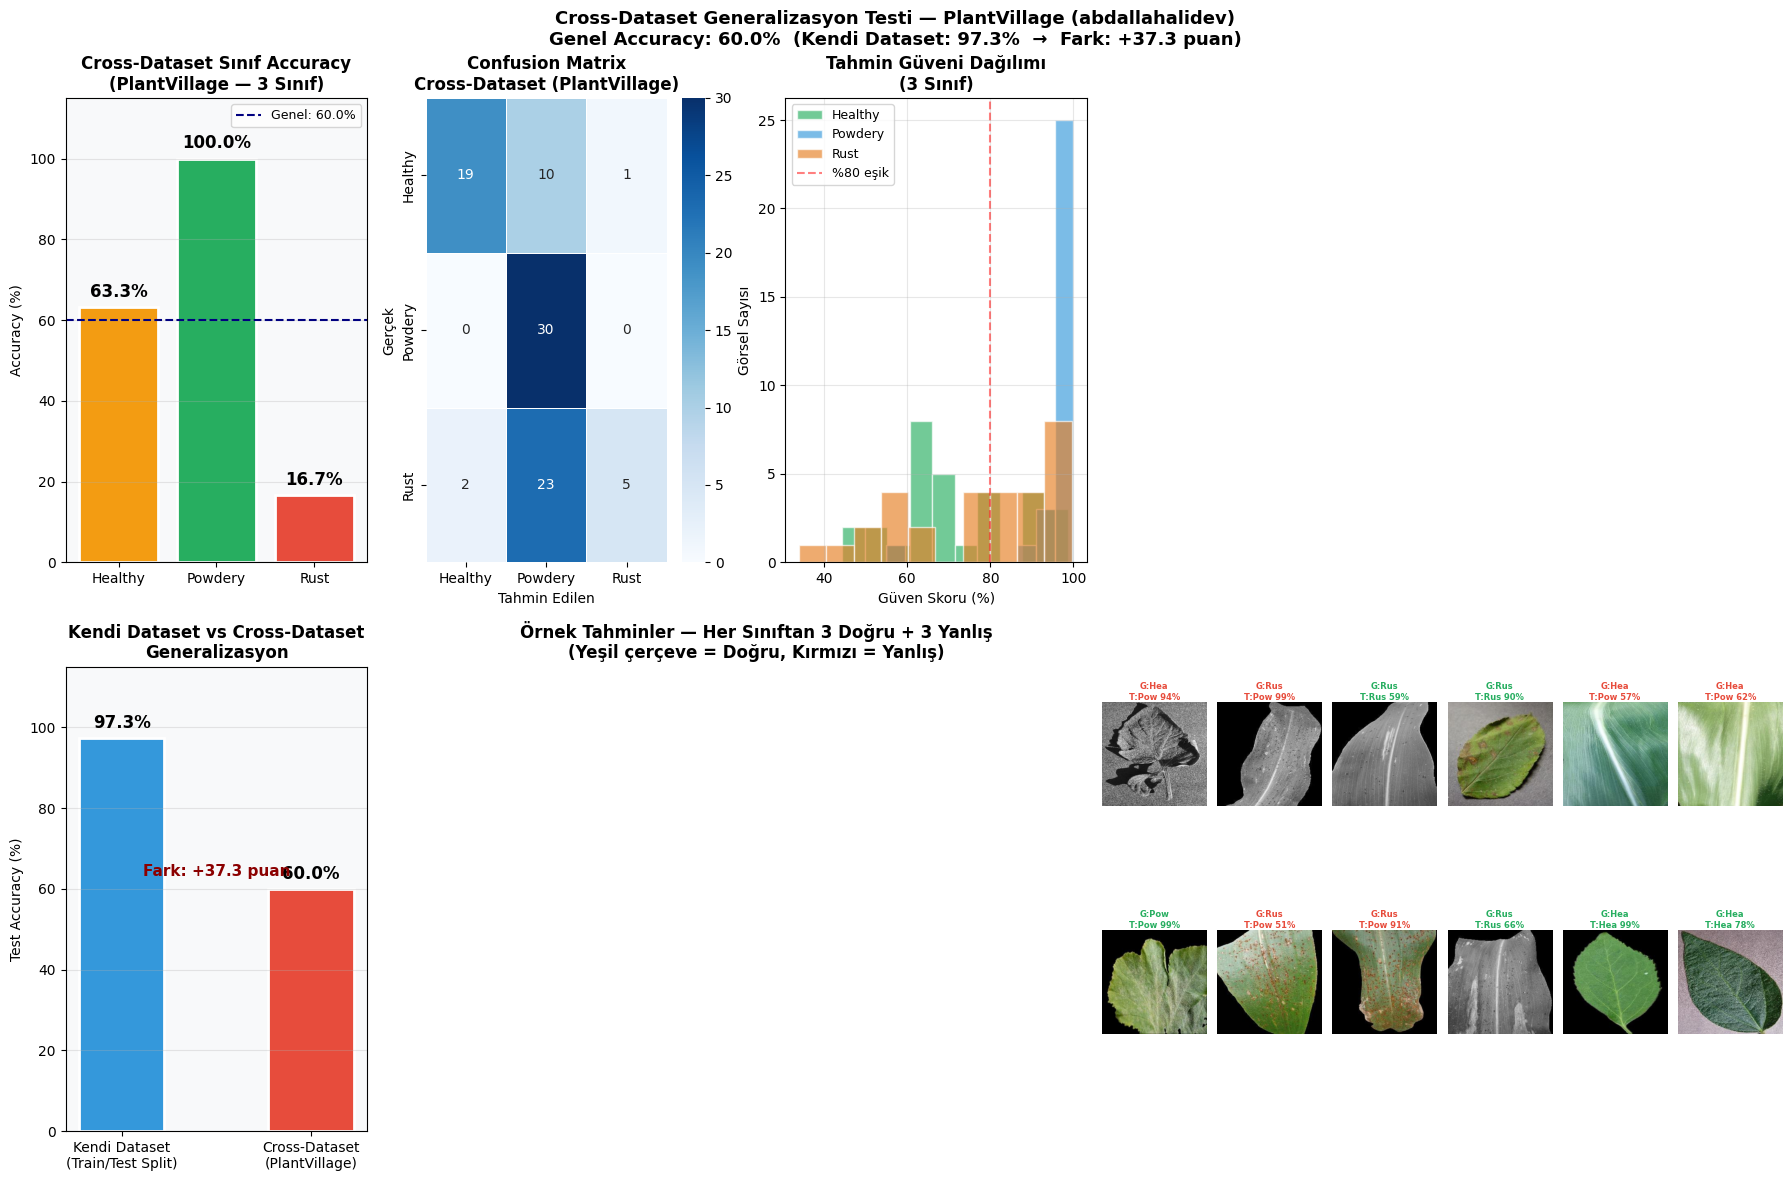


[KAYDEDİLDİ] cross_dataset_test_results.png

  CROSS-DATASET TEST — ÖZET RAPOR
  Dataset:              PlantVillage (abdallahalidev)
  Test edilen sınıflar: Healthy, Powdery, Rust
  Görsel/sınıf:         30
  Toplam test:          90

  Healthy   : 19/30  (63.3%)  ort. güven: 71.4%
  Powdery   : 30/30  (100.0%)  ort. güven: 96.1%
  Rust      :  5/30  (16.7%)  ort. güven: 77.2%

  GENEL ACCURACY:  60.0%
  KENDİ DATASETİ:  97.3%
  DÜŞÜŞ:          +37.3 puan

  YORUM: Düşük genelleşme. Model kendi dataseti için özelleşmiş.
  Daha fazla çeşitlilik içeren eğitim seti önerilir.

  SUNUMDA SÖYLEYEBİLECEKLERİN:
  'Modelimizi hiç görmediği PlantVillage dataseti ile
   test ettik (farklı bitki türleri, farklı fotoğraf koşulları).
   3 sınıfın hepsi test edildi: Healthy, Powdery, Rust.
   Genel accuracy 60.0% olarak ölçüldü.
   Kendi datasetindeki 97.3%'e kıyasla 37.3 puan
   düşüş, domain shift'in beklenen etkisini gösteriyor.'


In [11]:
# ============================================================
# PlantVillage Dataset ile Cross-Dataset Model Testi
# Dataset: abdallahalidev/plantvillage-dataset (Kaggle)
# ============================================================
# AMAÇ:
#   Modeli, eğitim sırasında HİÇ görmediği farklı bir datasetteki
#   görsellerle test etmek. 3 sınıfın da (Healthy, Powdery, Rust)
#   bu datasette karşılığı var:
#
#   Healthy → Apple___healthy, Tomato___healthy, vb.
#   Powdery → Cherry_(including_sour)___Powdery_mildew
#              Squash___Powdery_mildew
#   Rust    → Apple___Cedar_apple_rust
#              Corn_(maize)___Common_rust_
# ============================================================

import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from PIL import Image
import random
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("=" * 60)
print("  PlantVillage — Cross-Dataset Generalizasyon Testi")
print("=" * 60)


# ============================================================
# BÖLÜM 1: DATASET İNDİRME
# ============================================================
# Bu dataset emmarex versiyonundan farklı:
#   - 3 sınıfımızın (Healthy/Powdery/Rust) hepsi mevcut
#   - 54,000+ görsel, 38 farklı hastalık kategorisi
#   - Elma, kiraz, mısır, domates, patates vb. bitkilerden

path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print(f"\n[OK] Dataset yolu: {path}")


# ============================================================
# BÖLÜM 2: KATEGORİ EŞLEŞTİRME
# ============================================================
# Bu dataset'in klasör isimleri:
#   "Apple___Cedar_apple_rust"  → lowercased: "apple___cedar_apple_rust"
#   "Cherry_(including_sour)___Powdery_mildew" → "...powdery_mildew"
#   "Apple___healthy"           → "apple___healthy"
#
# Eşleştirme stratejisi:
#   Her sınıf için birden fazla keyword tanımlıyoruz.
#   Klasör adı herhangi birini içeriyorsa → o sınıfa dahil.
#
# Neden "rust" yerine liste?
#   Sadece "rust" desek "thrust" gibi kelimeler de eşleşebilir.
#   Daha spesifik: "_rust" veya "rust_" ile çevrili olanlar.
#   Ama bu dataset'te risk düşük, direkt "rust" yeterli.

our_classes = ['Healthy', 'Powdery', 'Rust']

# Her sınıf için eşleşme keyword listesi (lowercase, substring match)
class_keywords = {
    'Healthy': ['healthy'],
    'Powdery': ['powdery'],
    'Rust':    ['rust'],
}

# Tüm klasörleri tara, görsel içerenleri eşleştir
matched_dirs = {cls: [] for cls in our_classes}

for root, dirs, files in os.walk(path):
    image_files = [f for f in files
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG', '.JPEG'))]
    if not image_files:
        continue
    folder_name = os.path.basename(root).lower()
    for cls in our_classes:
        for kw in class_keywords[cls]:
            if kw in folder_name:
                matched_dirs[cls].append((root, image_files))
                break  # Bir keyword eşleşti, diğerlerine bakma

print("\n[EŞLEŞTİRME SONUÇLARI]")
print(f"{'Sınıf':10s} {'Görsel':>8} {'Klasör':>8}  Örnekler")
print("-" * 70)
for cls in our_classes:
    total  = sum(len(imgs) for _, imgs in matched_dirs[cls])
    folders = [os.path.basename(d) for d, _ in matched_dirs[cls]]
    print(f"{cls:10s} {total:>8,} {len(folders):>8}")
    for f in folders[:4]:
        print(f"             → {f}")
    if len(folders) > 4:
        print(f"             → ... ({len(folders) - 4} klasör daha)")

missing = [cls for cls in our_classes if not matched_dirs[cls]]
if missing:
    print(f"\n[UYARI] Eşleşme bulunamayan sınıflar: {missing}")
    print("         Keyword'leri güncelle veya dataset yapısını kontrol et.")
else:
    print(f"\n[OK] 3 sınıfın hepsi eşleşti ✓")


# ============================================================
# BÖLÜM 3: TEST GÖRSELLERİ SEÇME
# ============================================================
# Her sınıftan N_SAMPLES_PER_CLASS görsel rastgele seçiyoruz.
#
# Neden her sınıftan eşit sayı?
#   Dengeli test → accuracy metriği yanıltıcı olmaz.
#   (100 Healthy + 5 Powdery + 5 Rust olsaydı ve model
#    hepsine "Healthy" deseydi %90 accuracy alırdı → yanıltıcı!)
#
# Neden rastgele seçim?
#   Belirli görselleri seçersek o görsellere özel sonuç alırız.
#   Rastgele seçim → genel performansın daha adil ölçümü.

N_SAMPLES_PER_CLASS = 30  # Her sınıftan 30 görsel → toplam 90 test görseli
IMG_SIZE = (224, 224)      # EfficientNetB0 beklenen boyut

selected_images = []  # (img_array, true_label_idx, filepath)

print(f"\n[SEÇME] Her sınıftan {N_SAMPLES_PER_CLASS} görsel seçiliyor...")

random.seed(42)  # Tekrarlanabilirlik için sabit seed

for cls_idx, cls in enumerate(our_classes):
    if not matched_dirs[cls]:
        print(f"  {cls}: ATLAIDI (eşleşme yok)")
        continue

    # Bu sınıftaki tüm görsel yollarını topla
    all_paths = []
    for dirpath, image_files in matched_dirs[cls]:
        for img_file in image_files:
            all_paths.append(os.path.join(dirpath, img_file))

    # Rastgele N tane seç
    n      = min(N_SAMPLES_PER_CLASS, len(all_paths))
    chosen = random.sample(all_paths, n)

    # Her görseli yükle, boyutlandır, normalize et
    loaded = 0
    for img_path in chosen:
        try:
            img = Image.open(img_path).convert('RGB')  # RGBA/grayscale → RGB'ye çevir
            img = img.resize(IMG_SIZE, Image.LANCZOS)  # 224x224'e yeniden boyutlandır
            arr = np.array(img, dtype=np.float32) / 255.0  # [0, 255] → [0, 1]
            selected_images.append((arr, cls_idx, img_path))
            loaded += 1
        except Exception:
            pass  # Bozuk/okunamayan görsel → sessizce atla

    print(f"  {cls:10s}: {loaded:2d} görsel yüklendi  "
          f"(havuz: {len(all_paths):,} görsel, "
          f"{len(matched_dirs[cls])} klasör)")

print(f"\n  TOPLAM: {len(selected_images)} görsel hazır")


# ============================================================
# BÖLÜM 4: TAHMİN
# ============================================================
# Model beklentisi:
#   Input:  (N, 224, 224, 3), float32, değerler [0, 1]
#   Lambda katmanı içeride ×255 yaparak [0, 255]'e çevirir
#   Output: (N, 3) softmax olasılıkları
#           sütun 0 = Healthy, 1 = Powdery, 2 = Rust
#
# Neden batch predict?
#   Tek tek predict() → her görsel için GPU'ya ayrı çağrı → yavaş
#   Batch predict   → tüm görseller aynı anda işlenir → hızlı

print("\n[TAHMİN] Model çalıştırılıyor...")

X_test    = np.stack([item[0] for item in selected_images])   # (N, 224, 224, 3)
y_true    = np.array([item[1] for item in selected_images])   # (N,) integer labels
img_paths = [item[2] for item in selected_images]

predictions = efficientnet_model.predict(X_test, batch_size=32, verbose=1)
y_pred      = np.argmax(predictions, axis=1)   # En yüksek olasılıklı sınıf
confidences = np.max(predictions, axis=1)      # O sınıfa ait güven skoru

overall_acc = np.mean(y_pred == y_true)
print(f"\n[SONUÇ] Cross-Dataset Test Accuracy: {overall_acc*100:.1f}%")


# ============================================================
# BÖLÜM 5: SINIF BAZLI ANALİZ
# ============================================================
print("\n[SINIF BAZLI SONUÇLAR]")
print(f"{'':2s} {'Sınıf':10s} {'Doğru/Top':>12} {'Acc':>8} {'Ort.Güven':>11}")
print("  " + "-" * 48)

class_results = {}
for cls_idx, cls in enumerate(our_classes):
    mask = y_true == cls_idx
    if mask.sum() == 0:
        continue
    correct  = (y_pred[mask] == y_true[mask]).sum()
    total    = mask.sum()
    acc      = correct / total
    avg_conf = confidences[mask].mean()
    class_results[cls] = {
        'correct': correct, 'total': total,
        'acc': acc, 'avg_conf': avg_conf
    }
    icon = "✓" if acc >= 0.80 else ("~" if acc >= 0.60 else "✗")
    print(f"  {icon} {cls:10s} {correct:>5}/{total:<5}  "
          f"{acc*100:>7.1f}%  {avg_conf*100:>9.1f}%")


# ============================================================
# BÖLÜM 6: VİZÜELLEŞTİRME
# ============================================================
fig = plt.figure(figsize=(18, 12))

# --- GRAFIK 1: Sınıf bazlı accuracy ---
ax1 = fig.add_subplot(2, 3, 1)
cls_names = [c for c in our_classes if c in class_results]
cls_accs  = [class_results[c]['acc'] * 100 for c in cls_names]
colors    = ['#27ae60' if a >= 80 else ('#f39c12' if a >= 60 else '#e74c3c')
             for a in cls_accs]
bars = ax1.bar(cls_names, cls_accs, color=colors, edgecolor='white', linewidth=2)
ax1.set_title('Cross-Dataset Sınıf Accuracy\n(PlantVillage — 3 Sınıf)', fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(0, 115)
ax1.axhline(y=overall_acc * 100, color='navy', linestyle='--',
            linewidth=1.5, label=f'Genel: {overall_acc*100:.1f}%')
ax1.legend(fontsize=9)
for bar, acc in zip(bars, cls_accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax1.grid(axis='y', alpha=0.3)
ax1.set_facecolor('#f8f9fa')

# --- GRAFIK 2: Confusion Matrix ---
ax2 = fig.add_subplot(2, 3, 2)
valid_cls = [c for c in our_classes if c in class_results]
valid_idx = [our_classes.index(c) for c in valid_cls]
mask_v    = np.isin(y_true, valid_idx)
cm = confusion_matrix(y_true[mask_v], y_pred[mask_v], labels=valid_idx)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=valid_cls, yticklabels=valid_cls, linewidths=0.5)
ax2.set_title('Confusion Matrix\nCross-Dataset (PlantVillage)', fontweight='bold')
ax2.set_xlabel('Tahmin Edilen'); ax2.set_ylabel('Gerçek')

# --- GRAFIK 3: Güven dağılımı ---
ax3 = fig.add_subplot(2, 3, 3)
cls_colors_map = {'Healthy': '#27ae60', 'Powdery': '#3498db', 'Rust': '#e67e22'}
for cls_idx, cls in enumerate(our_classes):
    if cls not in class_results:
        continue
    mask = y_true == cls_idx
    ax3.hist(confidences[mask] * 100, bins=10, alpha=0.65,
             label=cls, color=cls_colors_map[cls], edgecolor='white')
ax3.set_title('Tahmin Güveni Dağılımı\n(3 Sınıf)', fontweight='bold')
ax3.set_xlabel('Güven Skoru (%)'); ax3.set_ylabel('Görsel Sayısı')
ax3.axvline(x=80, color='red', linestyle='--', alpha=0.5, label='%80 eşik')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)

# --- GRAFIK 4: Kendi dataset vs Cross-dataset karşılaştırma ---
ax4 = fig.add_subplot(2, 3, 4)
own_acc   = 97.33  # Phase 2 test accuracy (eğitim datasetimiz)
cross_acc = overall_acc * 100
cats      = ['Kendi Dataset\n(Train/Test Split)', 'Cross-Dataset\n(PlantVillage)']
accs_comp = [own_acc, cross_acc]
bar_cols  = ['#3498db', '#27ae60' if cross_acc >= 80 else '#e74c3c']
bars4 = ax4.bar(cats, accs_comp, color=bar_cols,
                edgecolor='white', linewidth=2, width=0.45)
ax4.set_title('Kendi Dataset vs Cross-Dataset\nGeneralizasyon', fontweight='bold')
ax4.set_ylabel('Test Accuracy (%)')
ax4.set_ylim(0, 115)
for bar, acc in zip(bars4, accs_comp):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
gap = own_acc - cross_acc
color_gap = 'darkred' if gap > 15 else ('darkorange' if gap > 8 else 'darkgreen')
ax4.text(0.5, 0.55, f'Fark: {gap:+.1f} puan', ha='center', fontsize=11,
         color=color_gap, transform=ax4.transAxes, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)
ax4.set_facecolor('#f8f9fa')

# --- GRAFIK 5: Doğru vs Yanlış tahmin örnek görseller ---
ax5 = fig.add_subplot(2, 3, (5, 6))
ax5.axis('off')
ax5.set_title('Örnek Tahminler — Her Sınıftan 3 Doğru + 3 Yanlış\n'
              '(Yeşil çerçeve = Doğru, Kırmızı = Yanlış)',
              fontweight='bold')

show_indices = []
for cls_idx in range(len(our_classes)):
    cls_mask    = np.where(y_true == cls_idx)[0]
    correct_sub = [i for i in cls_mask if y_pred[i] == y_true[i]]
    wrong_sub   = [i for i in cls_mask if y_pred[i] != y_true[i]]
    show_indices += random.sample(correct_sub, min(3, len(correct_sub)))
    show_indices += random.sample(wrong_sub,   min(3, len(wrong_sub)))

random.shuffle(show_indices)
show_indices = show_indices[:12]

n_cols = 6
n_rows = 2
for plot_i, idx in enumerate(show_indices[:12]):
    col = plot_i % n_cols
    row = plot_i // n_cols
    ax_sub = fig.add_axes([
        0.615 + col * 0.064,
        0.09  + (n_rows - 1 - row) * 0.19,
        0.058, 0.16
    ])
    ax_sub.imshow(X_test[idx])
    ax_sub.axis('off')
    is_correct   = (y_pred[idx] == y_true[idx])
    border_color = '#27ae60' if is_correct else '#e74c3c'
    for spine in ax_sub.spines.values():
        spine.set_visible(True)
        spine.set_color(border_color)
        spine.set_linewidth(3)
    t = our_classes[y_true[idx]][:3]
    p = our_classes[y_pred[idx]][:3]
    c = confidences[idx] * 100
    ax_sub.set_title(f"G:{t}\nT:{p} {c:.0f}%",
                     fontsize=6, color=border_color,
                     fontweight='bold', pad=1)

plt.suptitle(
    f'Cross-Dataset Generalizasyon Testi — PlantVillage (abdallahalidev)\n'
    f'Genel Accuracy: {overall_acc*100:.1f}%  '
    f'(Kendi Dataset: {own_acc:.1f}%  →  Fark: {own_acc - overall_acc*100:+.1f} puan)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout(rect=[0, 0, 0.615, 1])
plt.savefig('cross_dataset_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n[KAYDEDİLDİ] cross_dataset_test_results.png")


# ============================================================
# BÖLÜM 7: ÖZET RAPOR
# ============================================================
print("\n" + "=" * 60)
print("  CROSS-DATASET TEST — ÖZET RAPOR")
print("=" * 60)
print(f"  Dataset:              PlantVillage (abdallahalidev)")
print(f"  Test edilen sınıflar: {', '.join(cls_names)}")
print(f"  Görsel/sınıf:         {N_SAMPLES_PER_CLASS}")
print(f"  Toplam test:          {len(selected_images)}")
print()
for cls in cls_names:
    r = class_results[cls]
    print(f"  {cls:10s}: {r['correct']:2d}/{r['total']:2d}  "
          f"({r['acc']*100:.1f}%)  ort. güven: {r['avg_conf']*100:.1f}%")
print()
print(f"  GENEL ACCURACY:  {overall_acc*100:.1f}%")
print(f"  KENDİ DATASETİ:  {own_acc:.1f}%")
print(f"  DÜŞÜŞ:          {own_acc - overall_acc*100:+.1f} puan")
print()

if overall_acc >= 0.85:
    yorum = ("Güçlü genelleşme. Transfer learning'den gelen özellikler\n"
             "  farklı bitki türleri ve fotoğraf koşullarına dayanıklı.")
elif overall_acc >= 0.65:
    yorum = ("Makul genelleşme. Düşüş beklenen bir durum:\n"
             "  farklı bitki türü + farklı fotoğraf koşulları = domain shift.")
else:
    yorum = ("Düşük genelleşme. Model kendi dataseti için özelleşmiş.\n"
             "  Daha fazla çeşitlilik içeren eğitim seti önerilir.")

print(f"  YORUM: {yorum}")
print()
print("  SUNUMDA SÖYLEYEBİLECEKLERİN:")
print(f"  'Modelimizi hiç görmediği PlantVillage dataseti ile")
print(f"   test ettik (farklı bitki türleri, farklı fotoğraf koşulları).")
print(f"   3 sınıfın hepsi test edildi: Healthy, Powdery, Rust.")
print(f"   Genel accuracy {overall_acc*100:.1f}% olarak ölçüldü.")
print(f"   Kendi datasetindeki {own_acc:.1f}%'e kıyasla {own_acc-overall_acc*100:.1f} puan")
print(f"   düşüş, domain shift'in beklenen etkisini gösteriyor.'")
print("=" * 60)
